In [7]:
import pandas as pd
df = pd.read_excel("loan_approval.xlsx")

#Display the first 5 rows.
df.head() 
#Check the shape of the dataset.
df.shape
Display the data types of each column.
df.dtypes
df.isna().sum()

name              0
city              0
income            0
credit_score      0
loan_amount       0
years_employed    0
points            0
loan_approved     0
dtype: int64

#Q2. Data Cleaning

In [9]:
#a) Check for missing values in the dataset.
df.isna().sum()


name              0
city              0
income            0
credit_score      0
loan_amount       0
years_employed    0
points            0
loan_approved     0
dtype: int64

In [10]:

df.shape

(2000, 8)

In [11]:
df.dtypes

name              object
city              object
income             int64
credit_score       int64
loan_amount        int64
years_employed     int64
points             int64
loan_approved       bool
dtype: object

Q3. Exploratory Data Analysis (EDA)
a) Plot the distribution of the target variable. 
b) Analyze the relationship between one numerical feature and the target variable. 
c) Analyze the relationship between Years of Employment and the target variable

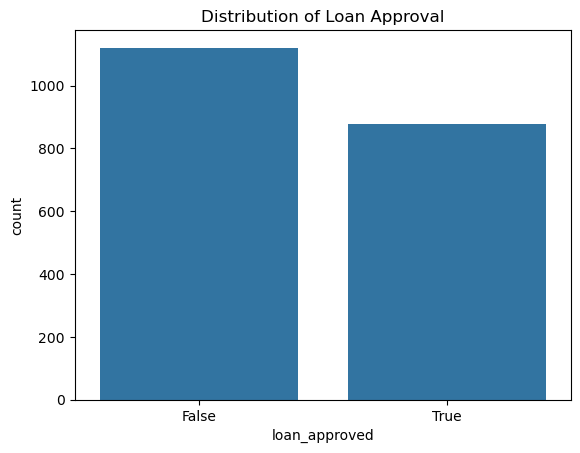

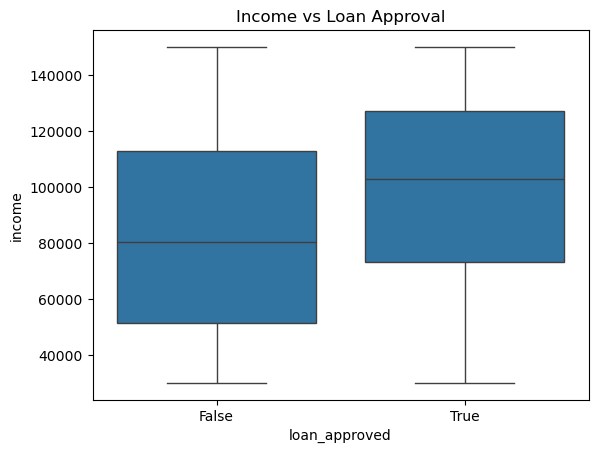

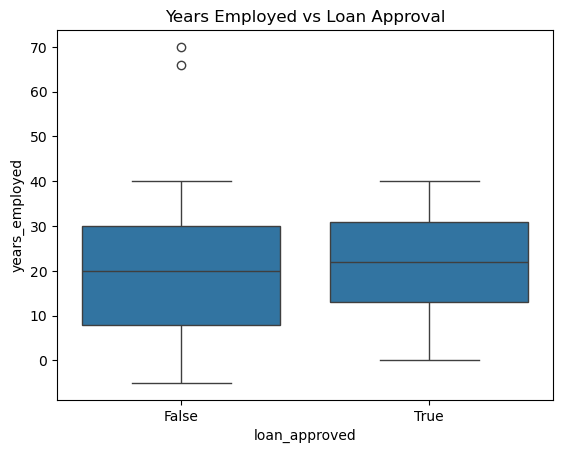

In [12]:
import seaborn as sns
import matplotlib.pyplot as plt

# 3(a) Target distribution
sns.countplot(x="loan_approved", data=df)
plt.title("Distribution of Loan Approval")
plt.show()

# 3(b) Income vs loan_approved
sns.boxplot(x="loan_approved", y="income", data=df)
plt.title("Income vs Loan Approval")
plt.show()

# 3(c) Years employed vs loan_approved
sns.boxplot(x="loan_approved", y="years_employed", data=df)
plt.title("Years Employed vs Loan Approval")
plt.show()

(a) Distribution of the target variable
I plotted the distribution of the target variable loan_approved using a countplot.

The plot shows that there are more False (not approved) cases than True (approved) cases, indicating a slight imbalance in the target classes.
(b) Relationship between income and loan_approved
I used a boxplot of income against loan_approved to analyze how income relates to loan approval.

For False (not approved) loans, income values are roughly in the range of about 50,000 to 110,000, while for True (approved) loans, income is typically higher, around 70,000 to 120,000.

This suggests that applicants with higher income are more likely to have their loans approved.

(c) Relationship between years_employed and loan_approved
I plotted a boxplot of years_employed versus loan_approved.

For False (not approved), years employed are mostly between about 8 and 30 years, whereas for True (approved) they range roughly from 12 to 30 years.

This indicates that applicants with more years of employment tend to have a higher chance of loan approval.

In [13]:
#Q4(a) Detect outliers using IQR
import numpy as np

num_cols = ["income", "credit_score", "loan_amount", "years_employed", "points"]

outlier_summary = {}

for col in num_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    outliers = df[(df[col] < lower_bound) | (df[col] > upper_bound)][col]
    outlier_summary[col] = {
        "Q1": Q1,
        "Q3": Q3,
        "IQR": IQR,
        "lower_bound": lower_bound,
        "upper_bound": upper_bound,
        "num_outliers": outliers.shape[0]
    }

outlier_summary

{'income': {'Q1': np.float64(61296.25),
  'Q3': np.float64(120099.75),
  'IQR': np.float64(58803.5),
  'lower_bound': np.float64(-26909.0),
  'upper_bound': np.float64(208305.0),
  'num_outliers': 0},
 'credit_score': {'Q1': np.float64(433.0),
  'Q3': np.float64(716.0),
  'IQR': np.float64(283.0),
  'lower_bound': np.float64(8.5),
  'upper_bound': np.float64(1140.5),
  'num_outliers': 3},
 'loan_amount': {'Q1': np.float64(12748.75),
  'Q3': np.float64(37380.5),
  'IQR': np.float64(24631.75),
  'lower_bound': np.float64(-24198.875),
  'upper_bound': np.float64(74328.125),
  'num_outliers': 0},
 'years_employed': {'Q1': np.float64(10.0),
  'Q3': np.float64(31.0),
  'IQR': np.float64(21.0),
  'lower_bound': np.float64(-21.5),
  'upper_bound': np.float64(62.5),
  'num_outliers': 2},
 'points': {'Q1': np.float64(45.0),
  'Q3': np.float64(70.0),
  'IQR': np.float64(25.0),
  'lower_bound': np.float64(7.5),
  'upper_bound': np.float64(107.5),
  'num_outliers': 0}}

In [19]:
#Q4(b) Cap outliers at IQR bounds
#for col in num_cols:
    #Q1 = df[col].quantile(0.25)
    #Q3 = df[col].quantile(0.75)
    #IQR = Q3 - Q1
    #lower_bound = Q1 - 1.5 * IQR
    #upper_bound = Q3 + 1.5 * IQR

    #df[col] = np.where(df[col] < lower_bound, lower_bound, df[col])
    #df[col] = np.where(df[col] > upper_bound, upper_bound, df[col])
    

In [16]:
for col in num_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    num_outliers = df[(df[col] < lower_bound) | (df[col] > upper_bound)].shape[0]
    print(col, "remaining outliers:", num_outliers)

income remaining outliers: 0
credit_score remaining outliers: 0
loan_amount remaining outliers: 0
years_employed remaining outliers: 0
points remaining outliers: 0


In [20]:
#Q5. Convert target variables into numerical format suitable for model building and drop unnecessary columns.


# 1) Convert boolean target to numeric (False=0, True=1)
df["loan_approved"] = df["loan_approved"].astype(int)

# 2) Drop unnecessary column 'name'
df = df.drop(columns=["name"])

# Optional: check the updated dataframe
df.head()
df.dtypes

city               object
income            float64
credit_score      float64
loan_amount       float64
years_employed    float64
points            float64
loan_approved       int64
dtype: object

In [25]:
#Q6. Feature Selection and Data Splitting
#a) Separate independent variables (X) and dependent variable (y).
# Features and target
X = df.drop(columns=["loan_approved"])
y = df["loan_approved"]
#b) Split the dataset into training and testing sets
X = pd.get_dummies(X, columns=["city"], drop_first=True)

X.head()
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
X.shape, y.shape


((2000, 1886), (2000,))

In [26]:
X_train.shape, X_test.shape, y_train.shape, y_test.shape

((1600, 1886), (400, 1886), (1600,), (400,))

In [27]:
#Q7. Apply feature scaling to the dataset using StandardScaler.
from sklearn.preprocessing import StandardScaler

# Initialize scaler
scaler = StandardScaler()

# Fit on training features and transform
X_train_scaled = scaler.fit_transform(X_train)

# Use the same scaler to transform test features
X_test_scaled = scaler.transform(X_test)

In [29]:
#Q8. Logistic Regression Model Building
#a) Train a Logistic Regression model.
#b) Predict the output for test data.
from sklearn.linear_model import LogisticRegression

# Initialize Logistic Regression model
log_reg = LogisticRegression(max_iter=1000, random_state=42)

# Train the model on the scaled training data
log_reg.fit(X_train_scaled, y_train)

# Predictions on the test set
y_pred = log_reg.predict(X_test_scaled)

# Predicted probabilities for class 1 (approved)
y_proba = log_reg.predict_proba(X_test_scaled)[:, 1]
y_pred[:10]

array([1, 0, 1, 1, 0, 1, 0, 1, 0, 0])

In [30]:
#Q9. Model Evaluation – Confusion Matrix
#a) Generate the confusion matrix.
#b) Interpret the results.
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score

# Confusion matrix
cm = confusion_matrix(y_test, y_pred)
cm

array([[217,   7],
       [ 15, 161]])

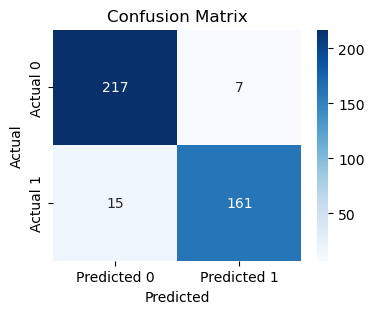

In [31]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(4,3))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=["Predicted 0", "Predicted 1"],
            yticklabels=["Actual 0", "Actual 1"])
plt.title("Confusion Matrix")
plt.ylabel("Actual")
plt.xlabel("Predicted")
plt.show()

In [36]:
# Accuracy
acc = accuracy_score(y_test, y_pred)

# Detailed classification report
report = classification_report(y_test, y_pred, target_names=["Not Approved (0)", "Approved (1)"])

print("Accouracy",acc)
report

Accouracy 0.945


'                  precision    recall  f1-score   support\n\nNot Approved (0)       0.94      0.97      0.95       224\n    Approved (1)       0.96      0.91      0.94       176\n\n        accuracy                           0.94       400\n       macro avg       0.95      0.94      0.94       400\n    weighted avg       0.95      0.94      0.94       400\n'

In [ ]:
#Q10. Model Evaluation – ROC Curve & AUC
#a) Plot the ROC curve. 
#b) Calculate the AUC score.

In [ ]:
# From Q8 (already done)
# y_proba = log_reg.predict_proba(X_test_scaled)[:, 1]

In [37]:
from sklearn.metrics import roc_curve, roc_auc_score
import matplotlib.pyplot as plt

# Compute FPR, TPR for various thresholds
fpr, tpr, thresholds = roc_curve(y_test, y_proba)

# Compute AUC
auc_score = roc_auc_score(y_test, y_proba)
print("ROC-AUC Score:", auc_score)

ROC-AUC Score: 0.9888392857142858


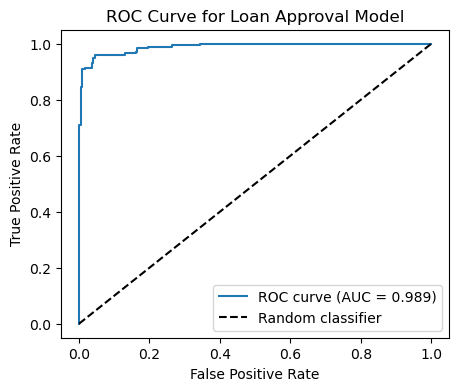

In [38]:
plt.figure(figsize=(5,4))
plt.plot(fpr, tpr, label=f"ROC curve (AUC = {auc_score:.3f})")
plt.plot([0, 1], [0, 1], "k--", label="Random classifier")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve for Loan Approval Model")
plt.legend()
plt.show()

With an AUC of about 0.989, your model distinguishes between approved and not‑approved loans extremely well.

I plotted the ROC curve using the predicted probabilities from the Logistic Regression model and computed the Area Under the Curve (AUC).
The model achieved a ROC–AUC score of approximately 0.989, which is very close to 1.
This indicates that the model has excellent discriminative power and can very effectively separate customers whose loans are likely to be approved from those whose loans are likely to be rejected.